## יחס נסיגה ולולאת עדכון — מתי אי אפשר לוקטר

(המשך הסרטון מ-9.8.) לאורך כל הקורס עד כה, וקטוריזציה **תמיד** עבדה: כל איבר במערך התוצאה חושב מהנתונים המקוריים, בלי תלות באיברי תוצאה אחרים. הפעם יש מצב שבו זה נשבר: כאשר **צעד $n$ תלוי בתוצאה של צעד $n-1$** — יחס נסיגה. אז חייבים לולאת עדכון אמיתית.

### דוגמה: סימולציית זריקה צעד-אחר-צעד (שיטת אוילר)

עד עכשיו חישבנו את מסלול הזריקה מנוסחה סגורה. נבנה אותו הפעם **צעד אחרי צעד**: בכל צעד זמן `dt`, המהירות והמיקום מתעדכנים לפי ערכם ב**צעד הקודם**:

$$v_{n+1} = v_n - g\,dt \qquad y_{n+1} = y_n + v_n\, dt$$

זו בדיוק השיטה שמשמשת בפועל לסימולציה נומרית כשאין נוסחה סגורה (ולמרות שכאן יש לנו נוסחה סגורה, זה תרגיל טוב להבנת ההבדל).

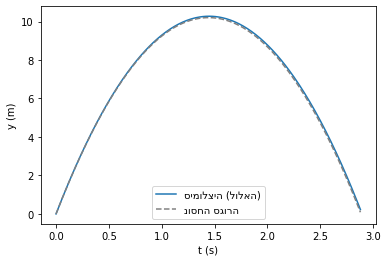

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.8
theta = np.radians(45)
v0 = 20.0
dt = 0.01

n_steps = int(2 * v0 * np.sin(theta) / g / dt) + 1

y_sim = np.zeros(n_steps)
vy_sim = np.zeros(n_steps)
vy_sim[0] = v0 * np.sin(theta)

for n in range(n_steps - 1):
    vy_sim[n+1] = vy_sim[n] - g * dt        # תלוי בערך הקודם - לא ניתן לוקטר
    y_sim[n+1] = y_sim[n] + vy_sim[n] * dt   # גם כאן

t_sim = np.arange(n_steps) * dt

fig, ax = plt.subplots()
ax.plot(t_sim, y_sim, label="סימולציה (לולאה)")
y_exact = v0 * np.sin(theta) * t_sim - 0.5 * g * t_sim**2
ax.plot(t_sim, y_exact, "--", color="gray", label="נוסחה סגורה")
ax.set_xlabel("t (s)")
ax.set_ylabel("y (m)")
ax.legend()
plt.show()

### באג נפוץ: ניסיון לוקטר יחס נסיגה

אפשר להתפתות לכתוב `vy_sim[1:] = vy_sim[:-1] - g * dt` בתקווה "לחסוך" את הלולאה — אבל זה **לא** עובד: הביטוי הזה מניח ש-`vy_sim[:-1]` כבר מכיל את הערכים הנכונים, אבל בזמן ההרצה כל האיברים עדיין אפסים (חוץ מהראשון) — אין "שרשור" אמיתי בין הצעדים כשכותבים את זה כפעולת מערך אחת.

In [2]:
vy_wrong = np.zeros(n_steps)
vy_wrong[0] = v0 * np.sin(theta)
vy_wrong[1:] = vy_wrong[:-1] - g * dt    # "וקטוריזציה" שגויה

print(vy_wrong[:5])   # כל האיברים (מלבד הראשון) התעדכנו פעם אחת בלבד מהאפס ההתחלתי
print(vy_sim[:5])     # הערכים הנכונים, מהלולאה

[14.14213562 14.04413562 -0.098      -0.098      -0.098     ]
[14.14213562 14.04413562 13.94613562 13.84813562 13.75013562]


ה"וקטוריזציה" השגויה מחשבת `vy_wrong[:-1] - g*dt` **פעם אחת**, מתוך המערך כפי שהיה *לפני* ההרצה — כמעט כולו אפסים חוץ מהאיבר הראשון. לכן רק `vy_wrong[1]` יוצא נכון (הוא מחושב מ-`vy_wrong[0]`, שכבר היה נכון), אבל `vy_wrong[2]` ואילך כולם מחושבים מ-**אפסים ישנים** ולא מהערכים המעודכנים בפועל — בדיוק כפי שרואים בהדפסה למעלה. ההבדל בין `vy_wrong` ל-`vy_sim` הוא בדיוק ההבדל בין "כל האיברים בבת אחת, מהמצב הישן" לבין "כל איבר תלוי בערך המעודכן של קודמו".

### נסו בעצמכם

הריצו את אותה סימולציה עם `dt=0.1` (גס יותר) והשוו חזותית לנוסחה הסגורה — מה קורה לדיוק?

In [3]:
# dt2 = 0.1
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
dt2 = 0.1
n_steps2 = int(2 * v0 * np.sin(theta) / g / dt2) + 1

y_sim2 = np.zeros(n_steps2)
vy_sim2 = np.zeros(n_steps2)
vy_sim2[0] = v0 * np.sin(theta)
for n in range(n_steps2 - 1):
    vy_sim2[n+1] = vy_sim2[n] - g * dt2
    y_sim2[n+1] = y_sim2[n] + vy_sim2[n] * dt2

t_sim2 = np.arange(n_steps2) * dt2
fig, ax = plt.subplots()
ax.plot(t_sim2, y_sim2, "o-", label="סימולציה (dt גס)")
ax.plot(t_sim, y_exact, "--", color="gray", label="נוסחה סגורה")
ax.legend()
plt.show()
```
עם `dt` גס יותר הסימולציה סוטה יותר מהפתרון המדויק — שגיאת הקירוב גדלה. זה בדיוק סוג האיזון (דיוק מול מהירות ריצה) שנדחה לקורס ההמשך.
`````

### בדקו את עצמכם

In [4]:
from jupyterquiz import display_quiz

questions = [
    {
        "question": "למה אי אפשר לוקטר את החישוב <code>v[n+1] = v[n] - g*dt</code> בפעולת מערך אחת?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "כי NumPy לא תומך בחיסור", "correct": False, "feedback": "לא — חיסור נתמך היטב."},
            {"answer": "אפשר בהחלט לוקטר את זה - זו רק שאלה של סגנון", "correct": False, "feedback": "לא — ראינו שהתוצאה שגויה כשמנסים."},
            {"answer": "כי v[n] הוא תמיד מספר שלילי", "correct": False, "feedback": "לא קשור — אין קשר בין סימן הערך לבין האפשרות לוקטר את החישוב."},
            {"answer": "כי כל איבר תלוי בערך המעודכן של קודמו, וזה דורש שרשור צעד-אחר-צעד אמיתי", "correct": True, "feedback": "נכון."}
        ]
    }
]
display_quiz(questions)

<IPython.core.display.Javascript object>

### תרגול עצמי

כתבו לולאת עדכון שמדמה זריקה עם **חיכוך אוויר ליניארי** פשוט: $v_{n+1}=v_n - (g + k v_n)\,dt$ עבור $k=0.1$ (מקדם חיכוך שרירותי). זו דוגמה שבה **אין** נוסחה סגורה פשוטה — בדיוק המקרה שבו לולאת עדכון היא לא רק נוחות, אלא הכרח.

In [5]:
# k = 0.1
# ...

`````{admonition} פתרון
:class: dropdown, tip
```python
k = 0.1
vy_drag = np.zeros(n_steps)
vy_drag[0] = v0 * np.sin(theta)
for n in range(n_steps - 1):
    vy_drag[n+1] = vy_drag[n] - (g + k * vy_drag[n]) * dt

fig, ax = plt.subplots()
ax.plot(t_sim, vy_drag, label="עם חיכוך")
ax.plot(t_sim, vy_sim, "--", label="בלי חיכוך")
ax.set_xlabel("t (s)")
ax.set_ylabel(r"$v_y$ (m/s)")
ax.legend()
plt.show()
```
`````